# 14 — Classification as Simultaneous Control

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *Can one piecewise-constant control steer every training point into the region of its label, what does such a construction cost, and what does it say — and not say — about new data?*

Control theory asks a sharper question than training does: not "does gradient descent find a good classifier?" but "does a classifying control *exist*, and how complex must it be?" This notebook answers it for neural ODEs with ReLU activation, by solving the dynamics of one neuron exactly and assembling explicit controls. It ends with a pre-registered comparison: the **constructed** control against a **trained** residual network, on new data.

### Table of Contents

1. **The classification theorem and what it assumes**
2. **What one ReLU neuron does** — three basic actions, solved exactly
3. **A construction in the plane** — the 1-D triangular system, applied to heights
4. **Counting** — switches, amplitudes, horizon, width
5. **Laboratory: constructed versus trained, on new data from the two-class point cloud** — the registered joint evaluation
6. **Control ↔ ML**
7. **Deep non-residual networks: collapsing instead of sliding**
8. **Width, depth, clustering and probability**
9. **Exercises**

**Notation.** $x'=w(t)\sigma(a(t)\cdot x+b(t))$ with $\sigma(z)=\max\{z,0\}$ (ReLU) throughout; $w$ is the outer weight of the field, $\Theta$ all parameters, $N$ the total number of training points. A **switch** is a jump of the control inside $(0,T)$, so switches $=$ layers $-1$.

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0)
rng = np.random.default_rng(0);

## Where are we?

> **Recap.** A residual network is the Euler scheme of a neural ODE, training is simultaneous optimal control, and the discrete adjoint gives exact gradients. In [notebook 13](13_neuralodes.ipynb) a residual classifier for the two-class point cloud was *trained*, with a fixed readout (label $1$ iff $x^{(1)}(T)>1$), and its final evaluation was registered jointly with this notebook. In one dimension, $N$ ReLU neurons interpolate $N$ values through a triangular system.

Kalman's theorem said that few controls can steer many states. Supervised learning asks to steer *many copies* of the same system, one per data point, with *one* control. This notebook asks whether that is possible for neural ODEs, with which controls, and at what cost. It then compares a **constructed** control with the **trained** one, on new data, as registered before either was evaluated.

## 1. The classification theorem and what it assumes

> **Theorem (classification; Ruiz-Balet and Zuazua, 2023), as stated.** *Consider the neural ODE with the ReLU as activation function. Then, in any time horizon $[0,T]$, a finite arbitrary number of items can be driven to an arbitrary number of open subsets of the Euclidean space corresponding to their labels.*
> - *Controls are piecewise constant with a maximal number of $O(N)$ switches. They also lie in $BV$.*
> - *The control time $T>0$ can be made arbitrarily small (absorbed into $\|w\|$ by scaling).*
> - *The complexity of controls diminishes when initial data are structured in clusters or the control requirement is relaxed.*

The conclusion is about the **training items only**: their flow map images $\Phi_T(x_i)$ land in the open set attached to their label. Several hypotheses are needed that the bare statement does not print. We record them, without claiming that this is the exact list of the cited paper.

- **Distinct items, or compatible labels.** $\Phi_T$ is a map, so two identical inputs have the same image. If $x_i=x_j$ with different labels and disjoint target sets, no control can work. Coincident inputs with the same label are harmless. The function `check_compatible` detects the incompatible case.
- **Dimension $d\ge2$.** In one dimension the flow of $x'=f(x,\theta(t))$ preserves order: two solutions that met would coincide, by uniqueness. Take $x_1<x_2<x_3$ with labels $1,0,1$ and targets $\Omega_1=(1,\infty)$, $\Omega_0=(-\infty,1)$: we would need $\Phi_T(x_1)>1>\Phi_T(x_2)$, contradicting $\Phi_T(x_1)<\Phi_T(x_2)$. The statement, read literally, fails for $d=1$; the finer results of §8 do assume $d\ge2$.
- **Non-empty open targets**, one per label. Openness is what allows a margin.
- **The count $O(N)$** is a statement about how the number of switches grows with $N$, for a construction. It is not a lower bound, and its constant is not given.

The second bullet is exact for piecewise-constant controls. Running the same control on $[0,cT]$ with every $w$ divided by $c$ (and times multiplied by $c$) produces the same flow map. A shorter horizon is paid for with larger amplitudes (§4).

> **Predict.** The cell below checks two small data sets for compatibility. Which one cannot be classified by *any* flow?

In [2]:
# The two-class point cloud with its fixed 72/24/24 split (same data and split as in notebook 13).
# This notebook draws no random numbers of its own; the generator rng_joint below is reserved
# for the joint final sample and used exactly once, in section 5.
X6 = torch.cat([torch.randn(60, 2) * 0.45 + torch.tensor([-0.6, 0.0]),
                torch.randn(60, 2) * 0.45 + torch.tensor([1.3, 0.3])]).numpy()
y6 = np.repeat([0.0, 1.0], 60)
idx6 = rng.permutation(len(y6))
train6, val6, test6 = idx6[:72], idx6[72:96], idx6[96:]      # the test split is not used
rng_joint = np.random.default_rng(1314)

def check_compatible(X, y, tol=1e-12):
    # coinciding inputs with different labels make classification impossible for ANY flow map
    pairs = []
    for i in range(len(X)):
        for j in range(i + 1, len(X)):
            if np.linalg.norm(X[i] - X[j]) <= tol:
                if y[i] != y[j]:
                    raise ValueError(f"inputs {i} and {j} coincide but have labels {y[i]:g} and {y[j]:g}")
                pairs.append((i, j))
    return pairs

for name, X, y in (("three points, two of them equal with equal labels", [[0, 1], [0, 1], [2, 0]], [1, 1, 0]),
                   ("two equal points with different labels", [[0, 1], [0, 1]], [0, 1])):
    try:
        print(f"{name}: compatible, coinciding pairs {check_compatible(np.array(X, float), np.array(y))}")
    except ValueError as err:
        print(f"{name}: INCOMPATIBLE ({err})")

three points, two of them equal with equal labels: compatible, coinciding pairs [(0, 1)]
two equal points with different labels: INCOMPATIBLE (inputs 0 and 1 coincide but have labels 0 and 1)


## 2. What one ReLU neuron does: three basic actions, solved exactly

Take one neuron with a constant control $(w,a,b)$ on a time interval: $x'=w\,\sigma(a\cdot x+b)$. Geometrically: $a$ and $b$ define the hyperplane $H=\{a\cdot x+b=0\}$; $\sigma$ *activates* $\{a\cdot x+b>0\}$ and *freezes* $\{a\cdot x+b\le0\}$; and $w$ gives the direction of the field inside the active half-space. The dynamics can be solved in closed form. Let $s(t)=a\cdot x(t)+b$.

- **Frozen side.** If $s(0)\le0$, then $x(t)=x(0)$ for all $t$. The constant solution satisfies the equation, and it is the only one, since the field is Lipschitz.
- **Active side.** If $s(0)>0$, then as long as $s>0$, $s'=a\cdot x'=(a\cdot w)\,s$. So $s(t)=s(0)e^{(a\cdot w)t}$, which stays positive, and
$$
x(t)=x(0)+w\,s(0)\,\frac{e^{(a\cdot w)t}-1}{a\cdot w}\qquad\Big(\,=x(0)+w\,s(0)\,t\ \text{ if }a\cdot w=0\Big).
$$
Every active point moves on a straight line in the direction $w$. The fraction $(e^{ct}-1)/c$ tends to $t$ as $c\to0$, so the formula is continuous in $a\cdot w$.

| $a\cdot w$ | name | effect on the active half-space |
|---|---|---|
| $=0$ | parallel | $s$ is constant: each point slides parallel to $H$, at a speed proportional to its distance from $H$ (a *shear*) |
| $<0$ | contraction | $s\to0$ exponentially: points approach $H$ but never reach it |
| $>0$ | expansion | $s$ grows exponentially: points move away from $H$ |

**No point ever crosses $H$ during one action**, since $s$ keeps its sign. One half-space is left exactly invariant while the other is deformed — a kind of dynamics not found in mechanics. Crossing a hyperplane requires a change of control, i.e. a switch, i.e. a new layer.

> **Predict.** Apply each of the three actions, for the same hyperplane, to a grid of points. Which points move, and where do they go?

parallel ($a\cdot w = 0$)        a.w = +0.00: frozen points moved 0.0e+00; sign of s kept: True; |exact - Euler(h = 4e-04)| = 2.2e-13
contraction ($a\cdot w < 0$)     a.w = -0.90: frozen points moved 0.0e+00; sign of s kept: True; |exact - Euler(h = 4e-04)| = 8.1e-05
expansion ($a\cdot w > 0$)       a.w = +0.90: frozen points moved 0.0e+00; sign of s kept: True; |exact - Euler(h = 4e-04)| = 3.4e-04


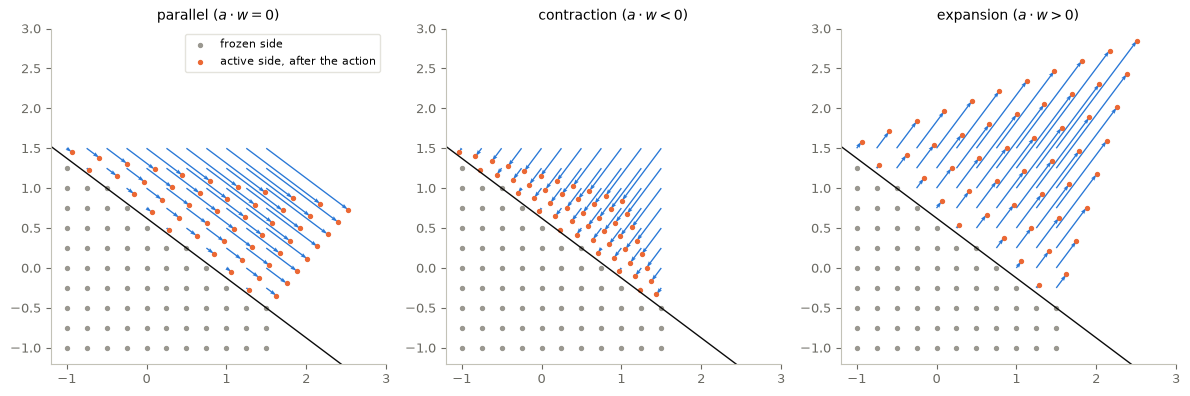

In [3]:
relu = lambda z: np.maximum(z, 0.0)

def relu_action_exact(X, w, a, b, t):
    # closed-form solution of x' = w relu(a.x + b) with constant control, from time 0 to t
    s0 = X @ a + b
    c = a @ w
    factor = (np.expm1(c * t) / c) if abs(c) > 1e-14 else t
    return X + np.outer(relu(s0) * factor, w)

def relu_euler(X, w, a, b, t, K):
    # the same action by K Euler steps (a ReLU ResNet)
    h, Z = t / K, X.copy()
    for _ in range(K):
        Z = Z + h * np.outer(relu(Z @ a + b), w)
    return Z

a_H, b_H, t_H = np.array([0.6, 0.8]), -0.5, 0.8                     # hyperplane 0.6 x1 + 0.8 x2 = 0.5
actions = {"parallel ($a\\cdot w = 0$)": np.array([0.8, -0.6]),
           "contraction ($a\\cdot w < 0$)": -0.9 * a_H,
           "expansion ($a\\cdot w > 0$)": 0.9 * a_H}
grid_pts = np.array([[x, y] for x in np.linspace(-1, 1.5, 11) for y in np.linspace(-1, 1.5, 11)])
s0 = grid_pts @ a_H + b_H
fig, axes = P.panels(3, figsize=(12, 3.9))
for ax, (name, w) in zip(axes, actions.items()):
    moved = relu_action_exact(grid_pts, w, a_H, b_H, t_H)
    euler = relu_euler(grid_pts, w, a_H, b_H, t_H, 2000)
    s_t = moved @ a_H + b_H
    print(f"{name:32s} a.w = {a_H @ w:+.2f}: frozen points moved "
          f"{np.abs(moved[s0 <= 0] - grid_pts[s0 <= 0]).max():.1e}; "
          f"sign of s kept: {bool(np.all((s_t > 0) == (s0 > 0)))}; "
          f"|exact - Euler(h = 4e-04)| = {np.abs(moved - euler).max():.1e}")
    ax.scatter(grid_pts[s0 <= 0, 0], grid_pts[s0 <= 0, 1], s=8, color=P.GREY, label="frozen side")
    ax.quiver(grid_pts[s0 > 0, 0], grid_pts[s0 > 0, 1], *(moved - grid_pts)[s0 > 0].T, angles="xy",
              scale_units="xy", scale=1, width=0.004, color=P.BLUE)
    ax.scatter(moved[s0 > 0, 0], moved[s0 > 0, 1], s=8, color=P.ORANGE, label="active side, after the action")
    xs = np.linspace(-1.2, 3, 2)
    ax.plot(xs, (-b_H - a_H[0] * xs) / a_H[1], color=P.INK, lw=1)
    P.label(ax, xlim=(-1.2, 3), ylim=(-1.2, 3), equal=True, title=name, legend=ax is axes[0])
plt.show()

**Figure 1.** The three basic actions of one ReLU neuron with constant control, for the same hyperplane $0.6x^{(1)}+0.8x^{(2)}=0.5$ (black line) and duration $0.8$: parallel ($a\cdot w=0$), contraction ($a\cdot w<0$), expansion ($a\cdot w>0$). Grey: points on the frozen side. Arrows: the exact displacement of each active point, from the closed-form solution.

*Interpretation (answer to the prediction).* Points below the line do not move at all (printed: displacement $0$). Every active point moves on a straight line in the direction $w$, and none crosses the line: the sign of $a\cdot x+b$ is preserved (printed). The shear moves points parallel to the line, faster the farther they are from it. The contraction pulls them towards the line, and the expansion pushes them away exponentially. The closed form agrees with a fine Euler simulation (a ReLU residual network) to the printed accuracy.

## 3. A construction in the plane

The theorem can be proved by *one step + induction*: move one point where it must go, without disturbing the others, and repeat. We give a **simpler construction of our own**. It is specific to $d=2$ and to the half-plane targets $\Omega_1=\{x^{(1)}>1\}$ and $\Omega_0=\{x^{(1)}<1\}$, with a margin. It uses only the parallel action.

**Ingredients.** Take $a=e_2$ and $w=v\,e_1$, so $a\cdot w=0$. The action $x'=v\,e_1\,\sigma(x^{(2)}-\beta)$ freezes the points with height $x^{(2)}\le\beta$ and moves the others horizontally, each at the constant speed $v\,(x^{(2)}-\beta)$. **Heights never change.** Every action is horizontal, so all actions see the same heights, and their horizontal displacements simply add up.

**The construction.** Let the $N$ training points have distinct heights $h_1<\dots<h_N$, after sorting.
1. Place a knot $\beta_1<h_1$ and knots $\beta_j=\frac12(h_{j-1}+h_j)$ for $j\ge2$.
2. Layer $j$ is the action with knot $\beta_j$ and speed $v_j$, for a time $\tau=T/N$. It moves exactly the points $j,\dots,N$ and leaves $1,\dots,j-1$ frozen.
3. After all layers, point $i$ has moved horizontally by $D(h_i)$, where
$$
D(h)=\tau\sum_{j=1}^Nv_j\,\sigma(h-\beta_j).
$$
4. Ask $D(h_i)=c_{y_i}-x_i^{(1)}$, with the target positions $c_1=1.5$ and $c_0=0.5$. Since $\sigma(h_i-\beta_j)=0$ for $j>i$ and $h_i-\beta_i>0$, this is a **lower-triangular system with positive diagonal**: a unique solution, by forward substitution.

This is the one-dimensional interpolation by ReLU neurons, applied to the height variable.

> **Proposition (construction).** *Assumptions:* $N$ points in $\mathbb R^2$ with distinct heights, labels in $\{0,1\}$, targets $c_0<1<c_1$. *Conclusion:* the $N$ parallel actions above send every point to first coordinate exactly $c_{y_i}$, i.e. into $\Omega_{y_i}$ with margin $\min(c_1-1,1-c_0)$, with $N$ constant segments (layers), hence at most $N-1$ switches, on any horizon $T>0$.

*Proof.* Heights are invariant and the frozen sets are exactly as described, so the final first coordinate of point $i$ is $x_i^{(1)}+D(h_i)=c_{y_i}$ by the triangular system. $\square$

**Distinct heights are not a real restriction.** If two distinct points share a height, they differ along the motion direction, and one preliminary parallel action *along $e_2$*, active everywhere, changes their heights by different amounts; `construct_classifier` adds that layer when needed and counts it. Identical points with different labels are rejected (§1). Other directions work too: with $a=(\sin\varphi,\cos\varphi)$ and $u\perp a$, "heights" are measured along $a$ and the motion is along $u$; the required horizontal landing is obtained by dividing by $u^{(1)}=\cos\varphi\ne0$.

> **Predict.** For the seven points below, whose labels alternate with height, how many layers will be needed, and what will a point that lies *between* two training heights do?

 layer   knot beta   speed v    points moved (by height rank)
     1      -1.400      14.000    [1, 2, 3, 4, 5, 6, 7]
     2      -0.100     -46.667    [2, 3, 4, 5, 6, 7]
     3       0.325     -63.467    [3, 4, 5, 6, 7]
     4       0.575     293.067    [4, 5, 6, 7]
     5       0.825    -477.867    [5, 6, 7]
     6       1.075     685.067    [6, 7]
     7       1.350    -938.933    [7]
layers 7, switches 6, largest speed 938.93, int |w| dt = 359.87
every point in the region of its label: True   margin 0.500
two new points between training heights end at x1 = [-1.8167 -4.8167]


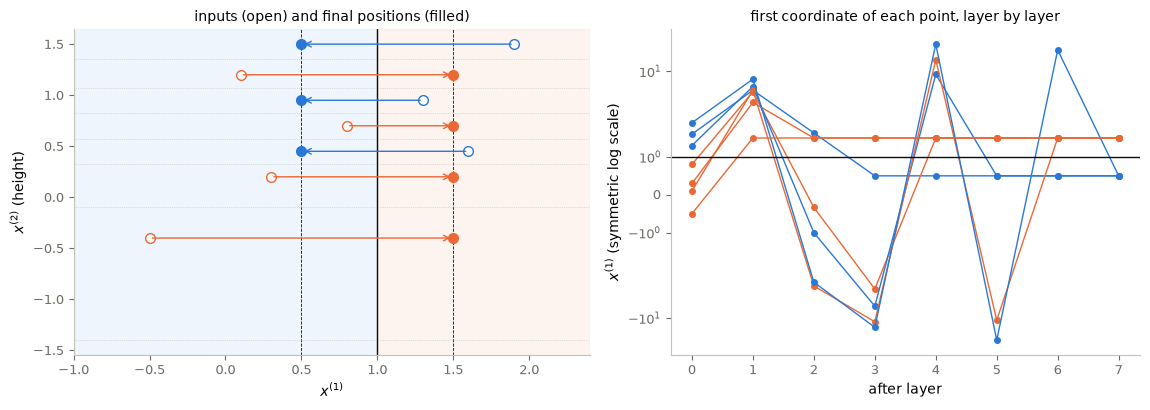

In [4]:
def construct_classifier(X, y, phi=0.0, targets=(0.5, 1.5), T=1.0, width=1):
    # The planar shear construction: heights along a = (sin phi, cos phi), motion along u = (cos phi, -sin phi).
    # Layers are (a, u, knots, time-integrated speeds): the parallel actions commute, so a layer of width P
    # displaces x by sum_p c_p relu(a.x - knot_p) u, with c_p = tau * v_p.
    a = np.array([np.sin(phi), np.cos(phi)])
    u = np.array([np.cos(phi), -np.sin(phi)])
    check_compatible(X, y)
    h = X @ a
    layers, extra = [], 0
    if np.min(np.diff(np.sort(h))) < 1e-9:                       # preliminary shear to separate tied heights
        g = X @ u
        beta0 = -g.min() + 1.0
        eps = 1e-3 / (np.abs(g + beta0).max())
        layers.append((u.copy(), a.copy(), np.array([-beta0]), np.array([eps])))   # heights along u, motion along a
        h = h + eps * (g + beta0)
        extra = 1
    order = np.argsort(h)
    hs = h[order]
    knots = np.concatenate([[hs[0] - 1.0], 0.5 * (hs[:-1] + hs[1:])])
    required = (np.array(targets)[y[order].astype(int)] - X[order, 0]) / u[0]      # displacement along u
    coeffs = np.zeros(len(hs))                                   # c_j = tau * v_j, by forward substitution
    for i in range(len(hs)):
        coeffs[i] = (required[i] - np.sum(coeffs[:i] * relu(hs[i] - knots[:i]))) / (hs[i] - knots[i])
    n_main = int(np.ceil(len(hs) / width))
    tau = T / (n_main + extra)
    for j in range(n_main):
        sel = slice(j * width, (j + 1) * width)
        layers.append((a.copy(), u.copy(), knots[sel].copy(), coeffs[sel].copy()))
    speeds = np.abs(coeffs) / tau
    return {"layers": layers, "n_layers": n_main + extra, "switches": n_main + extra - 1, "tau": tau,
            "max_speed": float(speeds.max()), "l1_in_time": float(np.abs(coeffs).sum()),
            "final_train": apply_layers(X, layers)}

def apply_layers(X, layers):
    # exact flow map of the constructed control (every layer is a commuting family of parallel actions)
    Z = X.copy()
    for a, u, knots, coeffs in layers:
        Z = Z + np.outer(relu(np.subtract.outer(Z @ a, knots)) @ coeffs, u)
    return Z

readout_label = lambda Z: (Z[:, 0] > 1).astype(float)
classify_constructed = lambda X, clf: readout_label(apply_layers(X, clf["layers"]))

X_core = np.array([[0.3, 0.2], [1.6, 0.45], [0.8, 0.7], [1.3, 0.95], [0.1, 1.2], [1.9, 1.5], [-0.5, -0.4]])
y_core = np.array([1, 0, 1, 0, 1, 0, 1])
clf_core = construct_classifier(X_core, y_core, phi=0.0, targets=(0.5, 1.5), T=1.0)
positions = [X_core]
rank = np.argsort(np.argsort(X_core[:, 1]))
print(" layer   knot beta   speed v    points moved (by height rank)")
for k, (a, u, knots, coeffs) in enumerate(clf_core["layers"]):
    moving = np.where(positions[-1] @ a > knots[0])[0]
    print(f"{k + 1:6d}   {knots[0]:9.3f}   {coeffs[0] / clf_core['tau']:9.3f}    "
          f"{sorted(int(r) + 1 for r in rank[moving])}")
    positions.append(apply_layers(positions[-1], [(a, u, knots, coeffs)]))
final_core = positions[-1]
margin_core = np.min((final_core[:, 0] - 1) * (2 * y_core - 1))
print(f"layers {clf_core['n_layers']}, switches {clf_core['switches']}, "
      f"largest speed {clf_core['max_speed']:.2f}, int |w| dt = {clf_core['l1_in_time']:.2f}")
print("every point in the region of its label:",
      bool(np.all(readout_label(final_core) == y_core)), f"  margin {margin_core:.3f}")

new_points = np.array([[1.0, 0.575], [1.0, 1.075]])              # between two training heights
print("two new points between training heights end at x1 =",
      np.round(apply_layers(new_points, clf_core["layers"])[:, 0], 4))

path = np.array(positions)                                       # (layers + 1, N, 2)
fig, (ax1, ax2) = P.panels(2, figsize=(11.6, 4.2), ratios=[1.1, 1])
ax1.axvspan(1, 2.4, color=P.ORANGE, alpha=0.07); ax1.axvspan(-1.0, 1, color=P.BLUE, alpha=0.07)
ax1.axvline(1, color=P.INK, lw=1); ax1.axvline(0.5, color=P.INK, lw=0.6, ls="--"); ax1.axvline(1.5, color=P.INK, lw=0.6, ls="--")
for a, u, knots, coeffs in clf_core["layers"]:
    ax1.axhline(knots[0], color=P.RULE, lw=0.5, ls=":")
for i in range(len(X_core)):
    c = P.ORANGE if y_core[i] == 1 else P.BLUE
    ax1.annotate("", xy=final_core[i], xytext=X_core[i], arrowprops=dict(arrowstyle="->", color=c, lw=1))
    ax1.plot(*X_core[i], "o", color=c, mfc="white", ms=7); ax1.plot(*final_core[i], "o", color=c, ms=7)
    ax2.plot(np.arange(len(path)), path[:, i, 0], "o-", color=c, ms=4, lw=1)
P.label(ax1, "$x^{(1)}$", "$x^{(2)}$ (height)", xlim=(-1.0, 2.4),
        title="inputs (open) and final positions (filled)")
ax2.set_yscale("symlog", linthresh=2); ax2.axhline(1, color=P.INK, lw=1)
P.label(ax2, "after layer", "$x^{(1)}$ (symmetric log scale)",
        title="first coordinate of each point, layer by layer")
plt.show()

**Figure 2.** The constructed control for seven points whose labels alternate with height (orange: label 1; blue: label 0). *Left:* inputs (open circles), final positions (filled) and the net horizontal displacement of each point. Dotted horizontal lines are the knots $\beta_j$ (each layer freezes everything below its knot). The readout line $x^{(1)}=1$ is solid and the targets $c_0=0.5$, $c_1=1.5$ are dashed; shading marks $\Omega_1$ (orange) and $\Omega_0$ (blue). *Right:* the first coordinate of each point after each layer, on a symmetric logarithmic scale.

*Interpretation (answer to the prediction).* Seven layers (six switches) suffice. The printed sequence of actions shows that layer $j$ moves only the points from height rank $j$ upwards, so a point, once placed, is never moved again. On the right, the point of height rank $j$ is moved only by layers $1$ to $j$: it overshoots in between, and from layer $j$ on it stays fixed on its target. Every point ends exactly on its target, with margin $0.5$, and all motion is horizontal. A new point between two training heights is moved by the same piecewise-linear displacement $D$, and ends wherever $D$ sends it: for the two printed points, far from both targets. The construction places the training points; it does not decide sensibly about the points in between.

## 4. Counting: switches, amplitudes, horizon, width

**Switches.** *Convention:* the control is constant on each of its $n$ pieces (layers), and a switch is a time at which it actually changes, so here switches $=n-1$; a preliminary layer, when needed, counts as a piece. The construction uses $N$ layers, so at most $N-1$ switches: $O(N)$, as in the theorem. Each switch changes $(w,a,b)$ at once, a *change of layer*. This count is an **upper bound** on the least number of switches needed for the data, not that least number.

**Amplitudes and the horizon.** Halving $T$ halves the duration $\tau$ of every layer, so every speed must double to produce the same displacements. The largest amplitude scales like $1/T$, while the $L^1$ size $\int_0^T|w(t)|\,dt$ is unchanged. This is the precise content of *"$T$ can be made arbitrarily small (absorbed into $\|w\|$ by scaling)"*. A short horizon is not free; it is paid for in amplitude.

**Amplitudes and the geometry of the data.** The diagonal entries of the triangular system are the gaps $h_i-\beta_i$, half the distance between consecutive heights. The speeds scale like the inverse gaps. Closely spaced heights with different labels need very large controls.

**Width.** With $P$ neurons per layer, $x'=\sum_{i=1}^Pw_i\sigma(a_i\cdot x+b_i)$, the parallel actions of $P$ consecutive knots can act **simultaneously**, because they move every point horizontally and leave heights unchanged. Grouping them gives $\lceil N/P\rceil$ layers, with **exactly the same final map**. This is a special, commuting case of the general width–depth trade-off:

- **Width versus depth.** *Increasing the width allows parallelising the consecutive actions of the switching controls and reducing depth: $O(N)\to O(1+N/p)$ layers.* The theorem behind this concerns **simultaneous control** $\Phi_T(x_i)=y_i$ (interpolation of target points), in dimension $d\ge2$, for pairs of different points; when $d\ge N+1$ the number of layers is $O(N/p)$ (§8).
- **Classification.** For width $1$, two classes of $N$ points each in general position in $\mathbb R^d$ with $2\le d<2N$, the number of switches is $O(1+N/d)$: higher dimension helps (§8).

Our construction does not prove these theorems. It shows the mechanism in a case where the actions commute, which is exactly why width can replace depth there without changing anything.

> **Predict.** For the seven points, what happens to the largest speed and to $\int|w|\,dt$ when $T$ goes from $1$ to $0.1$? How many layers are needed with width $2$, $3$, $7$?

In [5]:
print("   T     largest speed    int |w| dt    max change of the final positions")
for T in (1.0, 0.5, 0.1):
    c = construct_classifier(X_core, y_core, targets=(0.5, 1.5), T=T)
    print(f"{T:5.1f}   {c['max_speed']:13.2f}   {c['l1_in_time']:11.3f}   "
          f"{np.abs(c['final_train'] - final_core).max():.1e}")
print("width P   layers   switches   max change of the map on a test grid")
test_grid = np.array([[x, y] for x in np.linspace(-1, 2, 7) for y in np.linspace(-0.6, 1.8, 7)])
for Pw in (1, 2, 3, 7):
    c = construct_classifier(X_core, y_core, targets=(0.5, 1.5), width=Pw)
    change = np.abs(apply_layers(test_grid, c["layers"]) - apply_layers(test_grid, clf_core["layers"])).max()
    print(f"{Pw:7d}   {c['n_layers']:6d}   {c['switches']:8d}   {change:.1e}")
heights = np.sort(X_core[:, 1])
print(f"smallest height gap {np.diff(heights).min():.3f} -> largest speed {clf_core['max_speed']:.1f}")

   T     largest speed    int |w| dt    max change of the final positions
  1.0          938.93       359.867   0.0e+00
  0.5         1877.87       359.867   0.0e+00
  0.1         9389.33       359.867   0.0e+00
width P   layers   switches   max change of the map on a test grid
      1        7          6   0.0e+00
      2        4          3   1.8e-15
      3        3          2   8.9e-16
      7        1          0   7.1e-15
smallest height gap 0.250 -> largest speed 938.9


## 5. Laboratory: constructed versus trained, on new data from the two-class point cloud

The construction of §3 applies to any planar data set with compatible labels. We apply it to the **two-class point cloud**: 60 points per class in the plane, drawn from Gaussians with standard deviation $0.45$ centred at $(-0.6,0)$ and $(1.3,0.3)$, and split once into 72 training, 24 validation and 24 test points (the test split was spent on an earlier final evaluation and is not used). On the 72 training points, the construction is **procedure B** of the joint evaluation registered in notebook 13. Procedure A is the residual classifier trained there. Both use the same readout: label $1$ iff the first coordinate of the final state exceeds $1$.

**Protocol** (both procedures frozen before any joint data were generated).

- **Procedure A:** the trained residual classifier (width $8$, $\tanh$, $T=2$, $1000$ steps of full-batch Adam with adjoint gradients; depth and regularization chosen by the validation loss), re-run here from its frozen specification. It is deterministic, so it reproduces the original parameters and validation choice exactly (printed).
- **Procedure B:** the construction of §3, $T=1$, width $1$, targets $0.5$ and $1.5$, on the training split. The direction $\varphi\in\{0^\circ,30^\circ,60^\circ,120^\circ,150^\circ\}$ in which heights are measured is chosen by validation accuracy (ties to the smaller angle).
- **Joint final sample:** 2000 new, independent observations of the **population law of the point cloud**: a label $\sim$ Bernoulli$(\frac12)$ and a position drawn from that class's Gaussian (centre $(-0.6,0)$ or $(1.3,0.3)$, standard deviation $0.45$). Unlike the training design, the class sizes are not fixed. The sample comes from the reserved generator, is drawn once, after both procedures are fixed, and is not used for any choice.
- **Reported:** misclassification rates with Wilson 95% intervals, per-class error rates, and the discordant counts; **no winner is selected on these data**.

> **Predict.** Both procedures classify all 72 training points correctly. Which one will do better on new points, and by how much?

In [6]:
X_tr, y_tr, X_val, y_val = X6[train6], y6[train6], X6[val6], y6[val6]

# Procedure B: the construction of section 3 on the training split; phi chosen on validation accuracy.
phis_deg = [0, 30, 60, 120, 150]
constructions = {deg: construct_classifier(X_tr, y_tr, phi=np.deg2rad(deg), targets=(0.5, 1.5), T=1.0)
                 for deg in phis_deg}
val_acc_B = {deg: float(np.mean(classify_constructed(X_val, c) == y_val)) for deg, c in constructions.items()}
phi_B = min(phis_deg, key=lambda deg: (-val_acc_B[deg], deg))
clf_B = constructions[phi_B]
print(" phi    training acc.   validation acc.   layers   largest speed")
for deg, c in constructions.items():
    tr_acc = np.mean(classify_constructed(X_tr, c) == y_tr)
    print(f"{deg:4d}   {tr_acc:13.3f}   {val_acc_B[deg]:15.3f}   {c['n_layers']:6d}   {c['max_speed']:13.2e}"
          + ("  <- B" if deg == phi_B else ""))

 phi    training acc.   validation acc.   layers   largest speed
   0           1.000             0.500       72        3.10e+06
  30           1.000             0.625       72        6.50e+05
  60           1.000             0.792       72        9.86e+05  <- B
 120           1.000             0.333       72        5.84e+05
 150           1.000             0.708       72        8.26e+05


A: selected (K, alpha) = (20, 0.0), validation accuracy 1.000 (same grid and initialization as notebook 13)


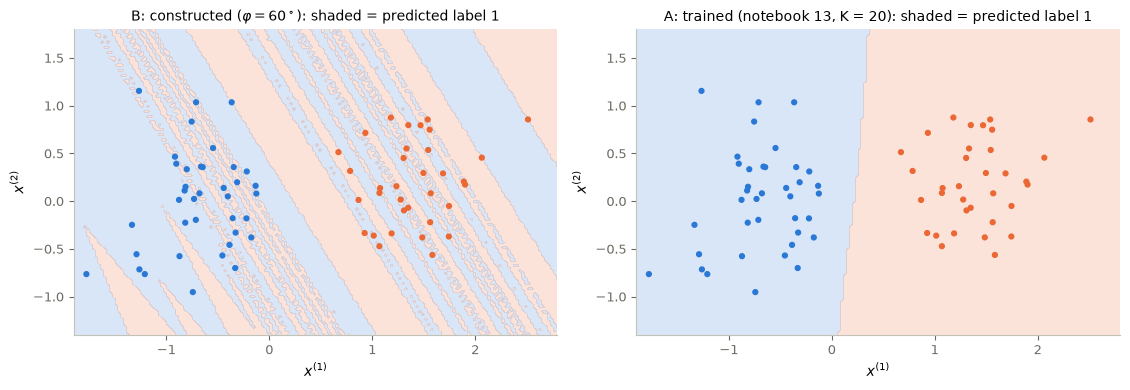

In [7]:
# Procedure A: the frozen procedure of notebook 13, re-run deterministically (same code, same grid).
def field_tanh(X, W, A, b):
    return np.tanh(X @ A.T + b) @ W.T

def euler_flow(X0, Theta, h):
    xs = [X0]
    for W, A, b in zip(*Theta):
        xs.append(xs[-1] + h * field_tanh(xs[-1], W, A, b))
    return np.array(xs)

expit = lambda z: 1 / (1 + np.exp(-z))

def dPhi_logistic(y, scale=4.0):
    def grad(X):
        out = np.zeros_like(X)
        out[:, 0] = scale * (expit(scale * (X[:, 0] - 1)) - y)
        return out
    return grad

def init_theta(K, P_width, d=2):
    Ws = np.zeros((K, d, P_width))
    ang = np.pi * (np.arange(P_width) + 0.5) / P_width - np.pi / 2
    As = np.tile(np.stack([np.cos(ang), np.sin(ang)], axis=1), (K, 1, 1))
    bs = np.tile(np.linspace(-0.5, 0.5, P_width), (K, 1))
    return Ws, As, bs

def adjoint_grad(X0, Theta, h, dPhi_term, alpha):
    Ws, As, bs = Theta
    xs = euler_flow(X0, Theta, h)
    n, K = len(X0), len(bs)
    p = dPhi_term(xs[-1]) / n
    gW, gA, gb = [], [], []
    for k in reversed(range(K)):
        x, W, A, b = xs[k], Ws[k], As[k], bs[k]
        z = x @ A.T + b
        s, ds = np.tanh(z), 1 - np.tanh(z) ** 2
        Wp = ds * (p @ W)
        gW.append(h * p.T @ s + 2 * alpha * h * W)
        gA.append(h * Wp.T @ x + 2 * alpha * h * A)
        gb.append(h * Wp.sum(0) + 2 * alpha * h * b)
        p = p + h * (Wp @ A)
    return np.array(gW[::-1]), np.array(gA[::-1]), np.array(gb[::-1])

def train_classifier(X, y, K, alpha, P_width=8, T=2.0, n_steps=1000, eta=0.05):
    h = T / K
    Theta = init_theta(K, P_width)
    shapes, sizes = [t.shape for t in Theta], [t.size for t in Theta]
    unpack = lambda f: tuple(seg.reshape(sh) for seg, sh in zip(np.split(f, np.cumsum(sizes)[:-1]), shapes))
    flat = np.concatenate([t.ravel() for t in Theta])
    m, v = np.zeros_like(flat), np.zeros_like(flat)
    for k in range(1, n_steps + 1):
        g = np.concatenate([t.ravel() for t in adjoint_grad(X, unpack(flat), h, dPhi_logistic(y), alpha)])
        m, v = 0.9 * m + 0.1 * g, 0.999 * v + 0.001 * g * g
        flat = flat - eta * (m / (1 - 0.9 ** k)) / (np.sqrt(v / (1 - 0.999 ** k)) + 1e-8)
    return unpack(flat), h

def mean_logistic(X, y, Theta, h, scale=4.0):
    z = scale * (euler_flow(X, Theta, h)[-1][:, 0] - 1)
    return float(np.mean(np.logaddexp(0, z) - y * z))

table_A, models_A = {}, {}
for K in (5, 10, 20):
    for alpha in (0.0, 1e-3, 1e-2, 1e-1):
        Theta_m, h_m = train_classifier(X_tr, y_tr, K, alpha)
        models_A[(K, alpha)] = (Theta_m, h_m)
        table_A[(K, alpha)] = {"validation loss": mean_logistic(X_val, y_val, Theta_m, h_m),
                               "validation accuracy": float(np.mean(
                                   readout_label(euler_flow(X_val, Theta_m, h_m)[-1]) == y_val))}
best_A = min(table_A, key=lambda ka: table_A[ka]["validation loss"])
Theta_A, h_A = models_A[best_A]
print(f"A: selected (K, alpha) = {best_A}, validation accuracy {table_A[best_A]['validation accuracy']:.3f} "
      f"(same grid and initialization as notebook 13)")

g1, g2 = np.meshgrid(np.linspace(-1.9, 2.8, 170), np.linspace(-1.4, 1.8, 120))
G = np.column_stack([g1.ravel(), g2.ravel()])
regions = {f"B: constructed ($\\varphi={phi_B}^\\circ$)": classify_constructed(G, clf_B).reshape(g1.shape),
           f"A: trained (notebook 13, K = {best_A[0]})": readout_label(euler_flow(G, Theta_A, h_A)[-1]).reshape(g1.shape)}
fig, axes = P.panels(2, figsize=(11.4, 4.0))
for ax, (name, reg) in zip(axes, regions.items()):
    ax.contourf(g1, g2, reg, levels=[-0.5, 0.5, 1.5], colors=[P.BLUE, P.ORANGE], alpha=0.18)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=np.where(y_tr == 1, P.ORANGE, P.BLUE), s=12)
    P.label(ax, "$x^{(1)}$", "$x^{(2)}$", title=name + ": shaded = predicted label 1")
plt.show()

**Figure 3.** The input plane, shaded where each procedure predicts label $1$, with the 72 training points coloured by their labels. *Left:* procedure B, the constructed control, with the direction chosen on validation data. *Right:* procedure A, the trained residual network.

*Interpretation (answer to the first part of the prediction).* Both procedures send every training point to the correct side; they disagree in between. The constructed control's decision region is a union of thin bands transverse to its height direction. Its displacement $D$ interpolates the required displacements of training points whose heights are very close but whose labels differ, so it oscillates violently between them (the printed speeds are enormous). The trained network's region follows the two clouds. Its loss and its control cost favoured a moderate deformation, and its parameters were chosen on validation data. Exact steering of the training points is a statement about controllability, not about prediction. The joint evaluation below measures the consequence on new data.

In [8]:
# Joint final evaluation, applied once after both procedures were frozen: 2000 new observations
# of the point cloud's population law from the reserved generator.
labels_joint = rng_joint.integers(0, 2, 2000)
centers = np.array([[-0.6, 0.0], [1.3, 0.3]])
X_joint = centers[labels_joint] + 0.45 * rng_joint.standard_normal((2000, 2))
y_joint = labels_joint.astype(float)
pred = {"A (trained, notebook 13)": readout_label(euler_flow(X_joint, Theta_A, h_A)[-1]),
        "B (constructed, this notebook)": classify_constructed(X_joint, clf_B)}

def wilson(k, n, z=1.959964):
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half

print(f"n = {len(y_joint)} (label 0: {np.sum(y_joint == 0)}, label 1: {np.sum(y_joint == 1)})")
for name, p_hat in pred.items():
    errors = int(np.sum(p_hat != y_joint))
    lo, hi = wilson(errors, len(y_joint))
    per_class = [float(np.mean(p_hat[y_joint == c] != c)) for c in (0, 1)]
    print(f"{name:31s} error rate {errors / len(y_joint):.3f}  [{lo:.3f}, {hi:.3f}]   "
          f"per class (0, 1): {per_class[0]:.3f}, {per_class[1]:.3f}")
right_A = pred["A (trained, notebook 13)"] == y_joint
right_B = pred["B (constructed, this notebook)"] == y_joint
print(f"discordant observations: A right / B wrong {int(np.sum(right_A & ~right_B))}, "
      f"A wrong / B right {int(np.sum(~right_A & right_B))}")

n = 2000 (label 0: 998, label 1: 1002)
A (trained, notebook 13)        error rate 0.021  [0.016, 0.028]   per class (0, 1): 0.030, 0.012
B (constructed, this notebook)  error rate 0.380  [0.359, 0.401]   per class (0, 1): 0.284, 0.476
discordant observations: A right / B wrong 739, A wrong / B right 21


**Reading the joint evaluation** *(answer to the second part of the prediction)*. The printed error rates, Wilson intervals and discordant counts are the registered comparison, computed once, after both procedures had been frozen; neither procedure was changed afterwards, and no choice in this course depends on them. For *these two procedures* and *this law*, the trained classifier is far more accurate than the constructed one, by much more than the sampling uncertainty of 2000 observations — statistical evidence about this comparison, not a certainty and not a ranking of trained versus constructed controls in general.

- They confirm, on independent data, what the validation accuracies already suggested (printed in §5).
- A control that steers every training point exactly demonstrates *capacity*. The trained network, whose loss and control cost favour a moderate deformation, *generalizes* on this task.

Two caveats limit the scope of the comparison. The two-class point cloud is a low-noise problem in the plane, with a readout that suits it. And B is our simple construction, not the one in the cited paper, whose purpose is existence and complexity, not prediction.

## 6. Control ↔ ML

- **Classification = simultaneous control.** **DIRECT CONNECTION.** One control steers all training points at once, each into the open set of its label. The fixed readout makes the target sets explicit.
- **Layers = switches of a piecewise-constant control.** **DIRECT CONNECTION** with switching control. A ResNet of ReLU neurons with constant controls on each layer is a switching control, and counting layers is counting switches.
- **Exact steering of training data = interpolation.** **DIRECT CONNECTION** with interpolation. Like exact interpolation by a shallow network, the construction fits every training point and nothing in it favours sensible behaviour in between. Controllability gives *capacity*; generalization needs a criterion that looks beyond the training points (a loss with a control cost, chosen on validation data, in procedure A).
- **Width versus depth.** **MATHEMATICAL ANALOGY** with parallel versus sequential actuation. Wider layers parallelize consecutive actions; in our commuting case exactly, in general only under the hypotheses of the cited theorems.

## 7. Deep non-residual networks: collapsing instead of sliding

Without the residual term, a layer is $x_{k+1}=\sigma(a_kx_k+b_k)$, with $a_k\in\mathbb R^{d_{k+1}\times d_k}$ and $\sigma$ applied entrywise. Its geometry is different. With one hyperplane, *all points on one side collapse to zero*. With two hyperplanes in the plane, the four regions cut out by them are mapped to four different places. The region where both pre-activations are positive is mapped bijectively onto the open quadrant, if $a_k$ is invertible. The two mixed regions are flattened onto the two half-axes. The region where both are $\le0$ is sent to the single point $(0,0)$. A residual layer with small steps is close to invertible; a non-residual ReLU layer is not injective. It *forgets* on purpose, which is how it merges points of the same class.

> **Result (Hernández and Zuazua, 2024), transcribed.** *A family of $N$ items in $d$ dimensions belonging to $M$ classes can be classified with width $2$ and depth $2N+4M-1$.* (We do not prove the result here.)

The cell below applies one width-2 non-residual layer to a grid, coloured by the sign pattern of the two pre-activations.

both <= 0        :  275 grid points ->    1 distinct images
only the 2nd > 0 :  261 grid points ->  197 distinct images
only the 1st > 0 :  173 grid points ->   30 distinct images
both > 0         :  252 grid points ->  252 distinct images


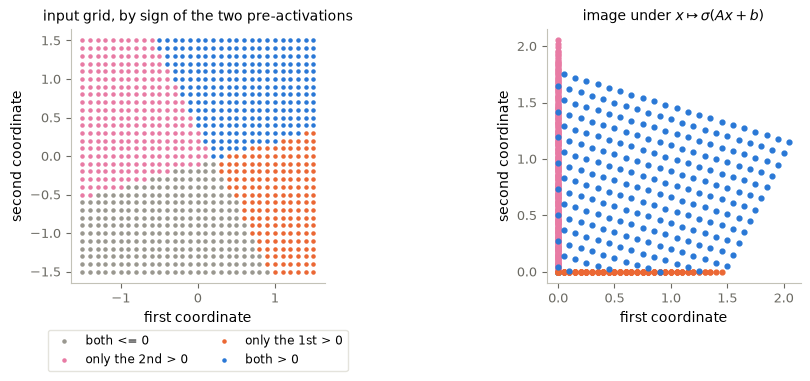

In [9]:
A_nr, b_nr = np.array([[1.0, 0.5], [-0.3, 1.0]]), np.array([-0.2, 0.1])
pts = np.array([[x, y] for x in np.linspace(-1.5, 1.5, 31) for y in np.linspace(-1.5, 1.5, 31)])
pre = pts @ A_nr.T + b_nr
image = np.maximum(pre, 0.0)
pattern = (pre[:, 0] > 0).astype(int) * 2 + (pre[:, 1] > 0).astype(int)    # 0: (-,-), 1: (-,+), 2: (+,-), 3: (+,+)
names = ["both <= 0", "only the 2nd > 0", "only the 1st > 0", "both > 0"]
cols = [P.GREY, P.MAGENTA, P.ORANGE, P.BLUE]
for k in range(4):
    sel = pattern == k
    print(f"{names[k]:17s}: {sel.sum():4d} grid points -> {len(np.unique(image[sel].round(12), axis=0)):4d} distinct images")
fig, (ax1, ax2) = P.panels(2, figsize=(10, 4))
for k in range(4):
    sel = pattern == k
    ax1.scatter(pts[sel, 0], pts[sel, 1], s=5, color=cols[k], label=names[k])
    ax2.scatter(image[sel, 0], image[sel, 1], s=12, color=cols[k])
P.label(ax1, "first coordinate", "second coordinate", equal=True,
        title="input grid, by sign of the two pre-activations",
        legend={"fontsize": 8.5, "loc": "upper center", "bbox_to_anchor": (0.5, -0.16), "ncol": 2})
P.label(ax2, "first coordinate", "second coordinate", equal=True,
        title=r"image under $x\mapsto\sigma(Ax+b)$")
plt.show()

**Figure 4.** One width-2 non-residual ReLU layer $x\mapsto\sigma(Ax+b)$. *Left:* an input grid coloured by the signs of the two pre-activations. *Right:* its image.

*Interpretation.* The region where both pre-activations are positive is mapped one-to-one onto part of the open quadrant. Each mixed region is flattened onto a half-axis, and the region where both are non-positive collapses to the origin: hundreds of grid points have a single image (printed counts). This is the opposite of the residual layers of §§2–3, which slide points without merging them. Merging is useful for classification, since points of one class can be sent to one place. It is also irreversible, which a flow never is.

## 8. Width, depth, clustering and probability

Several refinements exist, all for neural ODEs with ReLU activation. We transcribe their statements; none is proved here.

- **Simultaneous control with width $p$** (Álvarez-López, Hadj Slimane and Zuazua, 2024). For $d\ge2$ and $N$ pairs of different points, for any $T>0$ there is a piecewise-constant control with $O(1+N/p)$ discontinuities such that $\Phi_T(x_i)=y_i$ for all $i$. The proof controls $d-1$ coordinates first, then the last one. If $d>N$, the count is $O(N/p)$.
- **Autonomous fields.** With a constant control of width $p$, approximate steering holds with an error that decays like $\log_2(\kappa)/\kappa^{1/d}$ in the effective width $\kappa=(d+2)dp$: approximate, not exact, control by a very wide autonomous field, linked to turnpike theory.
- **Clustering and dimension** (Álvarez-López, Orive-Illera and Zuazua). For binary classification with the half-plane targets, $2\le d<2N$, and two classes of $N$ points in general position, width $1$ and $O(1+N/d)$ switches suffice. Clustered data need fewer.
- **Probabilistic statements** bound the probability that few switches suffice when the points are drawn uniformly in $[0,1]^d$. One exact ingredient: the probability that $N$ red and $N$ blue i.i.d. points on a line are separated by a threshold is $q_N=2/\binom{2N}{N}=\frac{2(N!)^2}{(2N)!}\approx\frac{\sqrt{\pi N}}{2^{2N-1}}$ (only 2 of the $\binom{2N}{N}$ equally likely colour orders work; the asymptotics is Stirling). With $d$ independent coordinates, the probability that at least one of them separates the classes is $1-(1-q_N)^d\approx1-e^{-q_Nd}$, which is small unless $d\gg4^N$: linear separability "for free" is rare, and the switching constructions are what remains.
- **Other architectures.** ReLU powers $\sigma_k(z)=(\max\{z,0\})^k$ give the same results for simultaneous control with a smaller static approximation error. Momentum neural ODEs $x''=w\sigma(a\cdot x+b)$ have the same capacity with $O(N)$ neurons, and two points can share the same position. Relaxed neural ODEs replace the sum of neurons by an integral against a probability measure $\mu$ over the parameters. What is linear in $\mu$ is the **field** $\int w\sigma(a\cdot x+b)\,d\mu$, for a fixed state $x$; the **flow** it generates, and any cost composed with that flow, depend on $\mu$ nonlinearly in general and need not be convex. The static relaxation of shallow networks, where the network output itself is linear in the measure, does not transfer automatically to the dynamic problem.

In [10]:
from math import comb, factorial, pi, sqrt
for N in (2, 5, 10, 20):
    q = 2 * factorial(N) ** 2 / factorial(2 * N)
    print(f"N = {N:2d}: 2(N!)^2/(2N)! = {q:.3e} = 2/binom(2N, N) = {2 / comb(2 * N, N):.3e};  "
          f"Stirling sqrt(pi N)/2^(2N-1) = {sqrt(pi * N) / 2 ** (2 * N - 1):.3e}")

N =  2: 2(N!)^2/(2N)! = 3.333e-01 = 2/binom(2N, N) = 3.333e-01;  Stirling sqrt(pi N)/2^(2N-1) = 3.133e-01
N =  5: 2(N!)^2/(2N)! = 7.937e-03 = 2/binom(2N, N) = 7.937e-03;  Stirling sqrt(pi N)/2^(2N-1) = 7.741e-03
N = 10: 2(N!)^2/(2N)! = 1.083e-05 = 2/binom(2N, N) = 1.083e-05;  Stirling sqrt(pi N)/2^(2N-1) = 1.069e-05
N = 20: 2(N!)^2/(2N)! = 1.451e-11 = 2/binom(2N, N) = 1.451e-11;  Stirling sqrt(pi N)/2^(2N-1) = 1.442e-11


## Key takeaways

1. The classification theorem concerns the training items: one piecewise-constant ReLU control can steer each into the open set of its label. It needs distinct (or compatibly labelled) inputs and $d\ge2$.
2. One ReLU neuron with constant control freezes a closed half-space and moves the other along $w$; the motion is solvable exactly. The three cases, parallel, contraction and expansion, are set by the sign of $a\cdot w$, and no point crosses the hyperplane.
3. In the plane, $N$ parallel actions reduce classification to a 1-D triangular construction in the height variable: $N$ layers, at most $N-1$ switches, exact landing with a margin.
4. Shortening the horizon multiplies the amplitudes; closely spaced heights with different labels need huge speeds; width can replace depth exactly when the actions commute, and in general under the hypotheses of the cited theorems.
5. Constructing a control that fits the training data is controllability, not learning. The pre-registered joint evaluation compares it with a trained network on new data.

## 9. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Which points move? ★** For the action $x'=w\sigma(a\cdot x+b)$ with $a=(1,-1)$, $b=0$, $w=(1,1)$ on the points $(2,1)$, $(1,2)$, $(0,0)$, $(3,-1)$: (a) which points move and in which direction? (b) Which of the three basic actions is it? (c) Can any of the points end on the line $x^{(1)}=x^{(2)}$ after a finite time?
2. **The exact solution. ★★** (a) Derive $s'=(a\cdot w)s$ for the active side and solve for $x(t)$. (b) Show that $x(t)\to x(0)+w\,s(0)\,t$ as $a\cdot w\to0$, uniformly for $t$ in bounded intervals. (c) For $a\cdot w<0$, find the limit of $x(t)$ as $t\to\infty$ and show that it lies on $H$.
3. **Horizon and amplitude. ★★** Let $(w,a,b)$ be piecewise constant on $[0,T]$ with flow map $\Phi_T$. (a) Show that the control $\tilde w(t)=c^{-1}w(t/c)$, $\tilde a(t)=a(t/c)$, $\tilde b(t)=b(t/c)$ on $[0,cT]$ has the same flow map. (b) How do $\sup_t|w|$, $\int|w|\,dt$ and $\int|w|^2dt$ change? (c) Which of them would make a "minimal-time" classification problem meaningful as a cost?
4. **The one-dimensional obstruction. ★★** (a) Prove that no control can make the exact flow of a scalar neural ODE send $x_1<x_2<x_3$, labelled $1,0,1$, into $\Omega_1=(1,\infty)$ and $\Omega_0=(-\infty,1)$. (b) Embed the three points in the plane as $(x_i,\,i/2)$ and use `construct_classifier` to classify them. (c) What changed between (a) and (b)?
5. **Width 2 halves the switches. ★★★** Starting from the width-1 construction `clf_core` of §3 (seven layers, each with one neuron), build by hand a control of **width 2**: group the neurons of consecutive layers two by two into layers of duration $T/\lceil N/2\rceil$, rescaling the speeds so that each neuron produces the same displacement. Apply it with `apply_layers` and check: (a) the number of layers is $\lceil7/2\rceil=4$, so the switches go from $6$ to $3$; (b) the final positions of the seven points, and the images of new points, are the same as with width 1; (c) explain why this works here, and why it would not work in general.
6. **Why the construction generalizes badly. ★★★** For procedure B of §5: (a) plot the total displacement $D(h)$ along the motion direction as a function of the height $h=a\cdot x$, on a fine grid of heights, together with the required displacements of the training points. (b) Relate its oscillations to the gaps between consecutive training heights with different labels. (c) Propose a modification that would trade exact landing for smaller oscillations, and say how you would choose its parameter **without** using the joint evaluation sample.

In [11]:
# TODO: student exercise (Exercise 5)
# A layer is (a, u, knots, coeffs) with one knot and coefficient per neuron (see apply_layers).

def pair_layers(layers, T):
    ...  # your code here
    return None

## Where are we going?

So far, individual points were steered. [Notebook 15](15_transformers.ipynb) lets the points interact: in a transformer, each token moves according to the positions of the others, and attention becomes a particle dynamics with its own clustering phenomena.

## References

1. D. Ruiz-Balet, E. Zuazua, [*Neural ODE control for classification, approximation, and transport*](https://doi.org/10.1137/21M1411433), SIAM Review **65** (2023), 735–773; [arXiv:2104.05278](https://arxiv.org/abs/2104.05278).
2. A. Álvarez-López, R. Hadj Slimane, E. Zuazua, [*Interplay between depth and width for interpolation in neural ODEs*](https://doi.org/10.1016/j.neunet.2024.106640), Neural Networks **180** (2024), 106640; [arXiv:2401.09902](https://arxiv.org/abs/2401.09902).
3. A. Álvarez-López, R. Orive-Illera, E. Zuazua, [*Optimized classification with neural ODEs via separability*](https://arxiv.org/abs/2312.13807), arXiv:2312.13807.
4. M. Hernández, E. Zuazua, [*Deep neural networks: multi-classification and universal approximation*](https://arxiv.org/abs/2409.06555), arXiv:2409.06555.
5. B. Geshkovski, E. Zuazua, [*Turnpike in optimal control of PDEs, ResNets, and beyond*](https://doi.org/10.1017/S0962492922000046), Acta Numerica **31** (2022), 135–263.